<a href="https://colab.research.google.com/github/CatherineMatangu/MyRepo_2026_Analytics2/blob/main/VideoAnalyticsPublicSafety.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simulated video saved as nairobi_street_sim.mp4


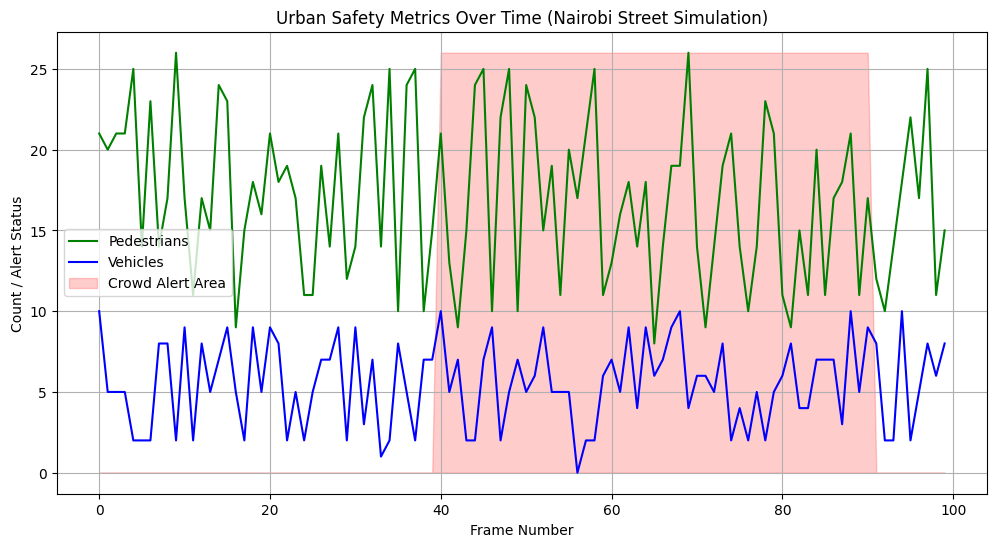


--- Safety Metrics Summary ---
Average Pedestrian Count: 17.01
Average Vehicle Count: 5.54
Total Crowd Alert Frames: 51


In [1]:
!pip install opencv-python
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set random seed for reproducibility
np.random.seed(42)

def create_simulated_video(filename='nairobi_street_sim.mp4', num_frames=100):
    """
    Generates a simulated video representing a Nairobi street scene.
    - Pedestrians: Green boxes
    - Vehicles: Blue boxes
    - Crowd Event: Red box with ALERT text (simulated between frames 40-90)
    """
    width, height = 640, 480
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(filename, fourcc, 10.0, (width, height))

    for i in range(num_frames):
        # Create a dark gray background for the street
        frame = np.ones((height, width, 3), dtype=np.uint8) * 100

        # Draw road area (gray)
        cv2.rectangle(frame, (100, 0), (540, height), (150, 150, 150), -1)

        # Simulate Pedestrians (Green)
        num_peds = np.random.randint(3, 8)
        for _ in range(num_peds):
            x = np.random.randint(100, 540)
            y = np.random.randint(0, height)
            cv2.rectangle(frame, (x, y), (x+15, y+30), (0, 255, 0), 2)

        # Simulate Vehicles (Blue)
        num_vehs = np.random.randint(1, 5)
        for _ in range(num_vehs):
            x = np.random.randint(150, 450)
            y = np.random.randint(0, height)
            cv2.rectangle(frame, (x, y), (x+40, y+60), (255, 0, 0), 2)

        # Simulate Crowd Gathering (Red) - Anomaly between frame 40 and 90
        if 40 <= i <= 90:
            cv2.rectangle(frame, (200, 150), (450, 350), (0, 0, 255), 3)
            cv2.putText(frame, "ALERT: CROWD GATHERING", (210, 140),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

        out.write(frame)

    out.release()
    print(f"Simulated video saved as {filename}")

def analyze_video(filename='nairobi_street_sim.mp4'):
    """
    Processes the video to extract safety metrics.
    """
    cap = cv2.VideoCapture(filename)
    metrics = []

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # 1. Video Segmentation (Road area - simple color-based approach)
        # In this simulation, road is (150, 150, 150)
        # For demonstration, we just count pixels in a specific range

        # 2. Object Detection (Simulated via color detection)
        # Detect Green (Pedestrians)
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        mask_green = cv2.inRange(hsv, (40, 40, 40), (80, 255, 255))
        ped_count = cv2.countNonZero(mask_green) // 100 # Approx normalization

        # Detect Blue (Vehicles)
        mask_blue = cv2.inRange(hsv, (100, 40, 40), (140, 255, 255))
        veh_count = cv2.countNonZero(mask_blue) // 300 # Approx normalization

        # Detect Red (Crowd Alert)
        mask_red = cv2.inRange(hsv, (0, 40, 40), (10, 255, 255))
        crowd_alert = 1 if cv2.countNonZero(mask_red) > 500 else 0

        metrics.append({
            'frame': frame_idx,
            'pedestrian_count': ped_count,
            'vehicle_count': veh_count,
            'crowd_alert': crowd_alert
        })
        frame_idx += 1

    cap.release()
    return pd.DataFrame(metrics)

def visualize_results(df):
    """
    Generates plots for the extracted metrics.
    """
    plt.figure(figsize=(12, 6))

    plt.plot(df['frame'], df['pedestrian_count'], label='Pedestrians', color='green')
    plt.plot(df['frame'], df['vehicle_count'], label='Vehicles', color='blue')
    plt.fill_between(df['frame'], 0, df['crowd_alert'] * max(df['pedestrian_count']),
                     color='red', alpha=0.2, label='Crowd Alert Area')

    plt.title('Urban Safety Metrics Over Time (Nairobi Street Simulation)')
    plt.xlabel('Frame Number')
    plt.ylabel('Count / Alert Status')
    plt.legend()
    plt.grid(True)
    plt.savefig('safety_metrics_plot.png')
    plt.show()

    # Summary Statistics
    avg_peds = df['pedestrian_count'].mean()
    avg_vehs = df['vehicle_count'].mean()
    total_alerts = df['crowd_alert'].sum()

    print("\n--- Safety Metrics Summary ---")
    print(f"Average Pedestrian Count: {avg_peds:.2f}")
    print(f"Average Vehicle Count: {avg_vehs:.2f}")
    print(f"Total Crowd Alert Frames: {total_alerts}")

if __name__ == "__main__":
    # 1. Create the simulated video
    create_simulated_video()

    # 2. Analyze the video
    results_df = analyze_video()

    # 3. Visualize and print summary
    visualize_results(results_df)